## Car Price prediction project

In [2]:
import pandas as pd
import numpy as np

In [3]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'
df = pd.read_csv(data)

In [4]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [5]:
df.count()

Make                 11914
Model                11914
Year                 11914
Engine Fuel Type     11911
Engine HP            11845
Engine Cylinders     11884
Transmission Type    11914
Driven_Wheels        11914
Number of Doors      11908
Market Category       8172
Vehicle Size         11914
Vehicle Style        11914
highway MPG          11914
city mpg             11914
Popularity           11914
MSRP                 11914
dtype: int64

### 1.Data preparation

In [6]:
# making colum names consistant
df.columns = df.columns.str.lower().str.replace(' ','_')
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [7]:
# making string columns value consitant
str_cols = df.dtypes[df.dtypes == 'str']
str_cols


make                 str
model                str
engine_fuel_type     str
transmission_type    str
driven_wheels        str
market_category      str
vehicle_size         str
vehicle_style        str
dtype: object

In [8]:
for col in list(str_cols.index):
    df[col]= df[col].str.lower().str.replace(' ','_')
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [9]:
df.isna().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [10]:
df.market_category.nunique()

71

In [11]:
df.engine_fuel_type.nunique()

10

### 2. Exploratory data analysis

In [12]:
import matplotlib as mpl
import seaborn as sb

## %matplotlib inline #assure that plots are displayed in jupyter notebook's cells

In [13]:
df.describe()

,year,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity,msrp
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [14]:
desc_dict = []
for col in df.columns:
    desc_dict.append({
        "col_name":col,
        "top_5_unique":list(df[col].unique())[:5],
        "number_of_unique":df[col].nunique(),
        "null_count":df[col].isnull().sum()
    })
desc= pd.DataFrame(desc_dict)
desc

,col_name,top_5_unique,number_of_unique,null_count
0,make,"[bmw, audi, fiat, mercedes-benz, chrysler]",48,0
1,model,"[1_series_m, 1_series, 100, 124_spider, 190-cl...",914,0
2,year,"[2011, 2012, 2013, 1992, 1993]",28,0
3,engine_fuel_type,"[premium_unleaded_(required), regular_unleaded...",10,3
4,engine_hp,"[335.0, 300.0, 230.0, 320.0, 172.0]",356,69
5,engine_cylinders,"[6.0, 4.0, 5.0, 8.0, 12.0]",9,30
6,transmission_type,"[manual, automatic, automated_manual, direct_d...",5,0
7,driven_wheels,"[rear_wheel_drive, front_wheel_drive, all_whee...",4,0
8,number_of_doors,"[2.0, 4.0, 3.0, nan]",3,6
9,market_category,"[factory_tuner,luxury,high-performance, luxury...",71,3742


In [15]:
df.msrp.min()

np.int64(2000)

In [16]:
df.msrp.max()

np.int64(2065902)

<Axes: xlabel='msrp', ylabel='Count'>

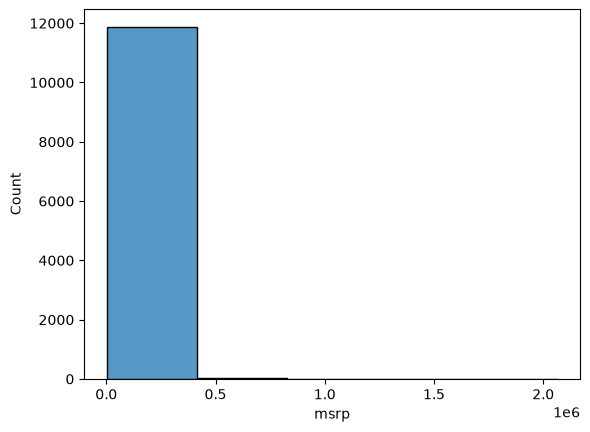

In [17]:
sb.histplot(df.msrp,bins=5)

<Axes: xlabel='msrp', ylabel='Count'>

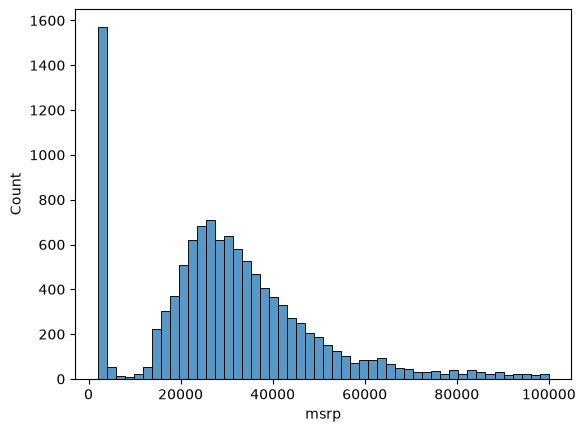

In [18]:
sb.histplot(df.msrp[(df.msrp<100000)],bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

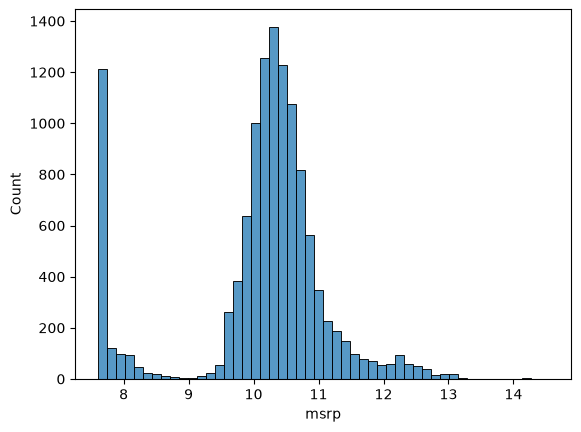

In [19]:
# for log(0) = -inf hence we should use log1p(0) = 0 
# but here I'm using log only because we don't have 0 in our msrp

price_log = np.log(df.msrp)
sb.histplot(price_log,bins=50)

In [20]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [21]:
df.market_category.head()

0    factory_tuner,luxury,high-performance
1                       luxury,performance
2                  luxury,high-performance
3                       luxury,performance
4                                   luxury
Name: market_category, dtype: str

In [22]:
df.market_category.str.split(',').head()

0    [factory_tuner, luxury, high-performance]
1                        [luxury, performance]
2                   [luxury, high-performance]
3                        [luxury, performance]
4                                     [luxury]
Name: market_category, dtype: object

##### Feature Engineering- Changing market_category to different columns 

In [23]:
uni = set()
for lst in list(df.market_category.str.split(',')):
    if isinstance(lst,float):
        continue
    for cat in lst:
        uni.add(cat)

uni


{'crossover',
 'diesel',
 'exotic',
 'factory_tuner',
 'flex_fuel',
 'hatchback',
 'high-performance',
 'hybrid',
 'luxury',
 'performance'}

In [24]:
header = []
for cat in uni:
    header.append(cat.replace('-','_'))

header

['flex_fuel',
 'hybrid',
 'crossover',
 'exotic',
 'luxury',
 'performance',
 'factory_tuner',
 'hatchback',
 'diesel',
 'high_performance']

In [25]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [26]:
for head in header:
    df["is_"+head]=df.market_category.str.contains(head)
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,...,is_flex_fuel,is_hybrid,is_crossover,is_exotic,is_luxury,is_performance,is_factory_tuner,is_hatchback,is_diesel,is_high_performance
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",...,False,False,False,False,True,True,True,False,False,False
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",...,False,False,False,False,True,True,False,False,False,False
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",...,False,False,False,False,True,True,False,False,False,False
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",...,False,False,False,False,True,True,False,False,False,False
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,...,False,False,False,False,True,False,False,False,False,False


In [27]:
for head in header:
    del df["is_"+head]
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


### 3. Validation Framework
1. calculate size
2. shuffle records
3. taking part with iloc
4. resetting index
5. parepare y and remove target 

In [28]:
n = len(df)
n

11914

In [29]:
test_n = int(n*0.2)
val_n = int(n*0.2)
train_n = n-test_n-val_n
train_n,val_n,test_n, n

(7150, 2382, 2382, 11914)

In [30]:
np.random.seed(3)

idx= np.arange(n)
np.random.shuffle(idx)
idx

array([ 8929,  8806,  7233, ..., 11513,  1688,  5994], shape=(11914,))

In [31]:
df_train = df.iloc[idx[:train_n]]
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
8929,volvo,s70,2000,regular_unleaded,190.0,5.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,24,17,870,2500
8806,gmc,s-15,1990,regular_unleaded,105.0,4.0,manual,rear_wheel_drive,2.0,NaN,compact,extended_cab_pickup,25,21,549,2000
7233,oldsmobile,ninety-eight,1995,regular_unleaded,225.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,sedan,26,17,26,2000
3535,aston_martin,dbs,2010,premium_unleaded_(required),510.0,12.0,automatic,rear_wheel_drive,2.0,"exotic,high-performance",midsize,convertible,18,12,259,283900
8763,chevrolet,s-10,2002,regular_unleaded,190.0,6.0,automatic,rear_wheel_drive,2.0,performance,compact,regular_cab_pickup,20,15,1385,21499


In [32]:
df_val = df.iloc[idx[train_n:train_n+val_n]]
df_test = df.iloc[idx[train_n+val_n:]]

In [33]:
len(df_train),len(df_val),len(df_test)

(7150, 2382, 2382)

In [34]:
df_train = df_train.reset_index(drop=True)
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,volvo,s70,2000,regular_unleaded,190.0,5.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,24,17,870,2500
1,gmc,s-15,1990,regular_unleaded,105.0,4.0,manual,rear_wheel_drive,2.0,NaN,compact,extended_cab_pickup,25,21,549,2000
2,oldsmobile,ninety-eight,1995,regular_unleaded,225.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,sedan,26,17,26,2000
3,aston_martin,dbs,2010,premium_unleaded_(required),510.0,12.0,automatic,rear_wheel_drive,2.0,"exotic,high-performance",midsize,convertible,18,12,259,283900
4,chevrolet,s-10,2002,regular_unleaded,190.0,6.0,automatic,rear_wheel_drive,2.0,performance,compact,regular_cab_pickup,20,15,1385,21499


In [35]:
df_val= df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [36]:
y_train  = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [37]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [38]:
df_train.head()
y_train

array([ 7.82444593,  7.60140233,  7.60140233, ...,  7.60140233,
        9.95683873, 10.30129004], shape=(7150,))

### 4. Linear Regrassion
- g(X) ≈ y # here X means all sample dataset
- g(xi) ≈ yi # here xi means only 1 same data (row)

In [39]:
df_train.iloc[0]

make                             volvo
model                              s70
year                              2000
engine_fuel_type      regular_unleaded
engine_hp                        190.0
engine_cylinders                   5.0
transmission_type            automatic
driven_wheels        front_wheel_drive
number_of_doors                    4.0
market_category                 luxury
vehicle_size                   midsize
vehicle_style                    sedan
highway_mpg                         24
city_mpg                            17
popularity                         870
Name: 0, dtype: object

In [40]:
# taking 3 features from sample data of volkswagen passat(2016)
xi = [190,17,870] # engine_hp, city_mpg, popularity
w0 = 0 # bios term
w = [1,1,1] # weight for each feature

In [41]:
def linear_reg(xi):
    # using linear regression formula

    n=len(xi)
    sum = w0

    for ind in range(n):
        sum += w[ind]*xi[ind]

    return sum


In [42]:
linear_reg(xi)

1077

In [43]:
# we assuming bois term and giving waightage to each feature
w0=7.17
w=[0.01,0.04,0.002]

In [44]:
linear_reg(xi)

11.49

In [45]:
# we got log value above converting back it to normal, we have to undo log
np.expm1(11.49)

np.float64(97732.53267762439)

In [46]:
np.log1p(97732.53267762439)

np.float64(11.49)

#### Linear Regression - Vector

In [47]:
def dot(xi,w):
    n=len(xi)

    res = 0
    for ind in range(n):
        res += xi[ind]*w[ind]

    return res

In [48]:
def linear_reg(xi):
    return w0 + dot(xi,w)

In [49]:
w_new = [w0] + w
w_new

[7.17, 0.01, 0.04, 0.002]

In [50]:
def linear_reg(xi):
    xi = [1] + xi
    return dot(xi,w_new)

linear_reg(xi)

11.49

In [51]:
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x3  = [1, 105, 21, 549]
x10 = [1, 453, 11, 86]

X = [x1, x2, x3, x10]
X = np.array(X)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  105,   21,  549],
       [   1,  453,   11,   86]])

In [52]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [53]:
def linear_regression(X):
    return X.dot(w_new)

linear_regression(X)

array([12.38 , 13.552, 10.158, 12.312])

#### Training Linear regression - normal equation

In [54]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]
X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [55]:
XTX = X.T.dot(X) # gram matrix
XTX

array([[ 696471,   44115,  718540],
       [  44115,    7146,  118803],
       [ 718540,  118803, 6359986]])

In [56]:
XTX_inv = np.linalg.inv(XTX)
XTX_inv

array([[ 2.35803616e-06, -1.46900642e-05,  8.00007928e-09],
       [-1.46900642e-05,  2.94487947e-04, -3.84130606e-06],
       [ 8.00007928e-09, -3.84130606e-06,  2.28083884e-07]])

In [57]:
XTX.dot(XTX_inv).round(1)

array([[ 1.,  0.,  0.],
       [-0.,  1.,  0.],
       [ 0.,  0.,  1.]])

In [58]:
# target vector y
y = [100, 200, 150, 250, 100, 200, 150, 250, 120]
y

[100, 200, 150, 250, 100, 200, 150, 250, 120]

In [59]:
# normal equestion gives us weight
w_full = XTX_inv.dot(X.T).dot(y)
w_full

array([0.26190562, 3.06101252, 0.03696909])

In [60]:
# adding bios term w0 (all 1 vector)
ones = np.ones(X.shape[0])
X = np.column_stack([ones, X])
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
w_full = XTX_inv.dot(X.T).dot(y)
w_full

array([ 3.00067767e+02, -2.27742529e-01, -2.57694130e+00, -2.30120640e-02])

In [61]:
w0= w_full[0]
w = w_full[1:]

In [62]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

### 5. Creating baseline model
1. selecting base features
2. Dealing with missing values
3. Training the model
4. comparing predictions with actual price

In [63]:
y_train

array([ 7.82444593,  7.60140233,  7.60140233, ...,  7.60140233,
        9.95683873, 10.30129004], shape=(7150,))

In [65]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,volvo,s70,2000,regular_unleaded,190.0,5.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,24,17,870
1,gmc,s-15,1990,regular_unleaded,105.0,4.0,manual,rear_wheel_drive,2.0,NaN,compact,extended_cab_pickup,25,21,549
2,oldsmobile,ninety-eight,1995,regular_unleaded,225.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,sedan,26,17,26
3,aston_martin,dbs,2010,premium_unleaded_(required),510.0,12.0,automatic,rear_wheel_drive,2.0,"exotic,high-performance",midsize,convertible,18,12,259
4,chevrolet,s-10,2002,regular_unleaded,190.0,6.0,automatic,rear_wheel_drive,2.0,performance,compact,regular_cab_pickup,20,15,1385


In [66]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [70]:
base_cols = ['engine_hp','engine_cylinders','highway_mpg', 'city_mpg', 'popularity']
X_train = df_train[base_cols].values
X_train

array([[1.900e+02, 5.000e+00, 2.400e+01, 1.700e+01, 8.700e+02],
       [1.050e+02, 4.000e+00, 2.500e+01, 2.100e+01, 5.490e+02],
       [2.250e+02, 6.000e+00, 2.600e+01, 1.700e+01, 2.600e+01],
       ...,
       [1.140e+02, 4.000e+00, 2.600e+01, 1.900e+01, 8.700e+02],
       [1.600e+02, 4.000e+00, 3.900e+01, 2.700e+01, 1.851e+03],
       [2.600e+02, 6.000e+00, 2.400e+01, 1.600e+01, 5.657e+03]],
      shape=(7150, 5))

In [72]:
df_train[base_cols].isnull().sum()

engine_hp           37
engine_cylinders    17
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [74]:
X_train = df_train[base_cols].fillna(0).values
X_train

array([[1.900e+02, 5.000e+00, 2.400e+01, 1.700e+01, 8.700e+02],
       [1.050e+02, 4.000e+00, 2.500e+01, 2.100e+01, 5.490e+02],
       [2.250e+02, 6.000e+00, 2.600e+01, 1.700e+01, 2.600e+01],
       ...,
       [1.140e+02, 4.000e+00, 2.600e+01, 1.900e+01, 8.700e+02],
       [1.600e+02, 4.000e+00, 3.900e+01, 2.700e+01, 1.851e+03],
       [2.600e+02, 6.000e+00, 2.400e+01, 1.600e+01, 5.657e+03]],
      shape=(7150, 5))

In [75]:
y_train

array([ 7.82444593,  7.60140233,  7.60140233, ...,  7.60140233,
        9.95683873, 10.30129004], shape=(7150,))

In [76]:
w0, w = train_linear_regression(X_train,y_train)
w0,w

(np.float64(7.9977910894411295),
 array([ 9.38137552e-03, -1.48981699e-01,  1.48986791e-02,  1.29814906e-02,
        -1.50934207e-05]))

In [77]:
y_predictions= w0+ X_train.dot(w)
y_predictions

array([ 9.60046631,  9.02370071,  9.82236895, ...,  9.0922238 ,
        9.80649519, 10.0229472 ], shape=(7150,))

<Axes: ylabel='Count'>

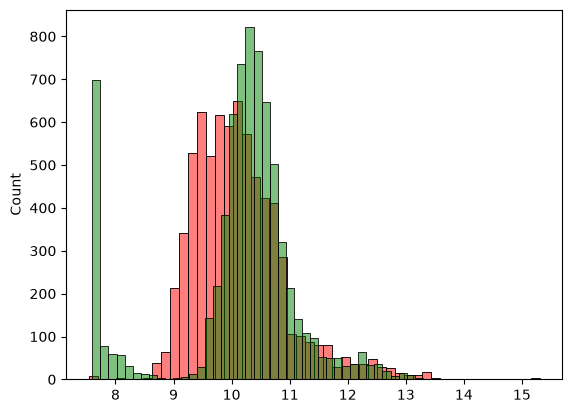

In [78]:
sb.histplot(y_predictions, color='red', alpha=0.5, bins=50)
sb.histplot(y_train, color='green', alpha=0.5, bins=50)

### 6. Root mean squeared error (RMSE)

In [79]:
def rmse(actual_target, predicted_target):
    error = actual_target - predicted_target
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

rmse(y_train,y_predictions)

np.float64(0.7530702635167187)

### 7. Computing RMSE on Validation data

In [80]:
def prepare_X(df):
    return df[base_cols].fillna(0).values

X_val = prepare_X(df_val)
X_val

array([[ 290.,    6.,   24.,   18., 1720.],
       [ 240.,    4.,   37.,   25.,  870.],
       [ 127.,    4.,   27.,   19.,  481.],
       ...,
       [ 330.,    6.,   26.,   18.,  190.],
       [ 134.,    4.,   18.,   15., 2009.],
       [ 200.,    4.,   31.,   21.,  873.]], shape=(2382, 5))

In [81]:
# we use same bios term(w0) and waitages(w) to check model accurecy using validation data
val_y_predictions = w0 + X_val.dot(w)
val_y_predictions

array([10.38977424, 10.51605153,  9.23495171, ..., 10.81791955,
        9.09154451,  9.9994332 ], shape=(2382,))

In [82]:
rmse(y_val,val_y_predictions)

np.float64(0.7460612947996899)

### 8. Feature Engineering

In [83]:
# here we will create new feature 'age' from column year
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,volvo,s70,2000,regular_unleaded,190.0,5.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,24,17,870
1,gmc,s-15,1990,regular_unleaded,105.0,4.0,manual,rear_wheel_drive,2.0,NaN,compact,extended_cab_pickup,25,21,549
2,oldsmobile,ninety-eight,1995,regular_unleaded,225.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,sedan,26,17,26
3,aston_martin,dbs,2010,premium_unleaded_(required),510.0,12.0,automatic,rear_wheel_drive,2.0,"exotic,high-performance",midsize,convertible,18,12,259
4,chevrolet,s-10,2002,regular_unleaded,190.0,6.0,automatic,rear_wheel_drive,2.0,performance,compact,regular_cab_pickup,20,15,1385


In [ ]:
# updating prepare_X for new age feature
def prepare_X(df):

    base_cols.append('age')
    new_df = df.copy()

    new_df['age'] = 2026 - new_df['year']

    return new_df[base_cols].fillna(0).values

X_train = prepare_X(df_train)
X_train

array([[1.900e+02, 5.000e+00, 2.400e+01, 1.700e+01, 8.700e+02, 2.600e+01],
       [1.050e+02, 4.000e+00, 2.500e+01, 2.100e+01, 5.490e+02, 3.600e+01],
       [2.250e+02, 6.000e+00, 2.600e+01, 1.700e+01, 2.600e+01, 3.100e+01],
       ...,
       [1.140e+02, 4.000e+00, 2.600e+01, 1.900e+01, 8.700e+02, 3.600e+01],
       [1.600e+02, 4.000e+00, 3.900e+01, 2.700e+01, 1.851e+03, 1.000e+01],
       [2.600e+02, 6.000e+00, 2.400e+01, 1.600e+01, 5.657e+03, 1.800e+01]],
      shape=(7150, 6))

In [85]:
# getting we weights after adding new column 'age'
w0 , w = train_linear_regression(X_train,y_train)
w0, w

(np.float64(10.178642257678275),
 array([ 3.82684201e-03,  7.19222188e-02, -2.73540685e-03,  9.40133852e-03,
        -5.25502530e-05, -9.26365359e-02]))

In [90]:
y_predictions = w0 + X_train.dot(w)
y_predictions

array([ 8.90525767,  7.6334271 ,  8.68681828, ...,  7.62946196,
       10.20214525,  9.72519172], shape=(7150,))

In [91]:
rmse(y_train,y_predictions)

np.float64(0.5190023824313631)

<Axes: ylabel='Count'>

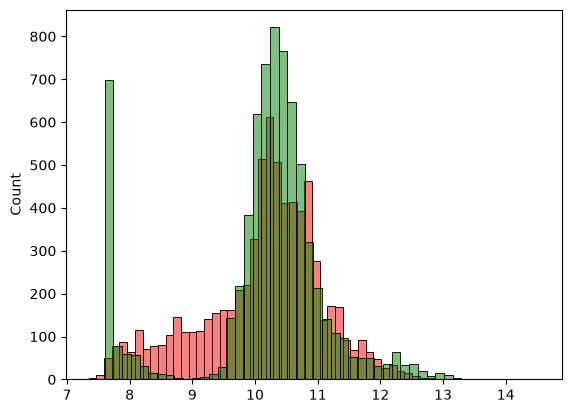

In [95]:
sb.histplot(y_predictions, label='prediction', color='red', alpha=0.5, bins=50)
sb.histplot(y_train, label='target', color='green',  alpha=0.5, bins=50)

#### Categorical variables

In [96]:
df.number_of_doors == 2

0         True
1         True
2         True
3         True
4         True
         ...  
11909    False
11910    False
11911    False
11912    False
11913    False
Name: number_of_doors, Length: 11914, dtype: bool

In [97]:
for door in [2,3,4]:
    df_train[f'num_doors_{door}'] = (df.number_of_doors == door).astype('int')

df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_doors_2,num_doors_3,num_doors_4
0,volvo,s70,2000,regular_unleaded,190.0,5.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,24,17,870,1,0,0
1,gmc,s-15,1990,regular_unleaded,105.0,4.0,manual,rear_wheel_drive,2.0,NaN,compact,extended_cab_pickup,25,21,549,1,0,0
2,oldsmobile,ninety-eight,1995,regular_unleaded,225.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,sedan,26,17,26,1,0,0
3,aston_martin,dbs,2010,premium_unleaded_(required),510.0,12.0,automatic,rear_wheel_drive,2.0,"exotic,high-performance",midsize,convertible,18,12,259,1,0,0
4,chevrolet,s-10,2002,regular_unleaded,190.0,6.0,automatic,rear_wheel_drive,2.0,performance,compact,regular_cab_pickup,20,15,1385,1,0,0


In [98]:
# creating function to get RMSE from new traning data
# use it after adding new features in prepare_X function to get new RMSE
def get_new_rmse_from_val_data():
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression(X_train,y_train)

    X_val = prepare_X(df_val)
    val_y_predictions = w0 + X_val.dot(w)

    return rmse(y_val,val_y_predictions)

In [100]:
def prepare_X(df):
    new_df = df.copy()
    features = base_cols.copy()

    new_df['age'] = 2026 - new_df['year']

    for v in [2, 3, 4]:
        new_df['num_doors_%s' % v] = (new_df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    df_num = new_df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

get_new_rmse_from_val_data()

np.float64(0.5127833091911798)

In [134]:
# adding all categorical variables
def prepare_X(df):
    new_df = df.copy()
    features = base_cols.copy()

    new_df['age'] = 2026 - new_df['year']
    features.append('age')

    for v in [2, 3, 4]:
        new_df['num_doors_%s' % v] = (new_df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    categorical_variables = [
        'make', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
        'market_category', 'vehicle_size', 'vehicle_style'
    ]

    categories = {}

    for c in categorical_variables:
        categories[c] = list(df_train[c].value_counts().head().index)

    for c, values in categories.items():
        for v in values:
            new_df[f'{c}_{v}'] = (new_df[c] == v).astype('int')
            features.append(f'{c}_{v}')


    df_num = new_df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

# get_new_rmse_from_val_data()

### 9. Regularization

In [ ]:
# In last code cell we got rmse too high due to noisy data
# hence we are using regularization technique using regularization parameter 'r'
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [105]:
# updating for new regularized model
def get_new_rmse_from_val_data_2():
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train,y_train,0.01)

    X_val = prepare_X(df_val)
    val_y_predictions = w0 + X_val.dot(w)

    return rmse(y_val,val_y_predictions)

In [106]:
get_new_rmse_from_val_data_2()

np.float64(0.48243627667591593)

### 10. Tunning the model
- Tunning means imporoving the quality of results and reducing rmse as much as posssible
- Tunning means we just find best value for regularization parameter 'r'

In [107]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train,y_train,r=r)

    X_val = prepare_X(df_val)
    val_y_predictions = w0 + X_val.dot(w)

    score= rmse(y_val,val_y_predictions)

    print(r, w0, score)

0.0 -3974550346067081.5 291.4535429172484
1e-05 7.532581593205175 0.48241288374932356
0.0001 6.982984816467614 0.48241415419982026
0.001 6.828235798566746 0.48241597153308374
0.1 6.68823043724751 0.48263984552975114
1 5.979698439720633 0.4847463807794084
10 4.531311298418098 0.5072010645509286


#### Training the final model

In [108]:
r = 0.00001
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train,y_train,r=r)

X_val = prepare_X(df_val)
val_y_predictions = w0 + X_val.dot(w)
rmse(y_val,val_y_predictions)

np.float64(0.48241288374932356)

1. Training the final model (train + val)
2. Checking model on test data
3. Predicting the price of car

In [109]:
df_full_train = pd.concat([df_train,df_val])
df_full_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_doors_2,num_doors_3,num_doors_4
0,volvo,s70,2000,regular_unleaded,190.0,5.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,24,17,870,1.0,0.0,0.0
1,gmc,s-15,1990,regular_unleaded,105.0,4.0,manual,rear_wheel_drive,2.0,NaN,compact,extended_cab_pickup,25,21,549,1.0,0.0,0.0
2,oldsmobile,ninety-eight,1995,regular_unleaded,225.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,sedan,26,17,26,1.0,0.0,0.0
3,aston_martin,dbs,2010,premium_unleaded_(required),510.0,12.0,automatic,rear_wheel_drive,2.0,"exotic,high-performance",midsize,convertible,18,12,259,1.0,0.0,0.0
4,chevrolet,s-10,2002,regular_unleaded,190.0,6.0,automatic,rear_wheel_drive,2.0,performance,compact,regular_cab_pickup,20,15,1385,1.0,0.0,0.0


In [110]:
df_full_train.reset_index(drop=True)
X_full_train = prepare_X(df_full_train)
X_full_train

array([[190.,   5.,  24., ...,   0.,   0.,   0.],
       [105.,   4.,  25., ...,   0.,   0.,   0.],
       [225.,   6.,  26., ...,   0.,   0.,   0.],
       ...,
       [330.,   6.,  26., ...,   0.,   0.,   0.],
       [134.,   4.,  18., ...,   0.,   0.,   0.],
       [200.,   4.,  31., ...,   0.,   0.,   1.]], shape=(9532, 42))

In [111]:
y_full_train = np.concatenate([y_train,y_val])
y_full_train

array([ 7.82444593,  7.60140233,  7.60140233, ..., 10.81679384,
        7.92407232, 10.11033911], shape=(9532,))

In [112]:
w0 , w = train_linear_regression_reg(X_full_train,y_full_train,r=0.00001)
w0,w

(np.float64(-8.485053506801048),
 array([ 1.57279794e-03,  1.17502329e-01, -7.14703443e-03, -4.86173934e-03,
        -5.84492402e-05, -4.82144977e-02, -4.81566736e-02, -7.96248154e-01,
        -9.05171654e-01, -6.46583765e-01, -3.13362186e-02,  2.08831586e-01,
        -1.00741991e-03, -9.62729523e-02, -7.94283202e-02, -4.66965480e-01,
         8.91383806e-02, -3.19015491e-01, -5.40255753e-01, -7.79269171e-02,
         1.46237009e+01,  1.44317064e+01,  1.46795615e+01,  1.61691201e+01,
         1.40383710e+01,  3.63054495e+00,  3.53209330e+00,  3.61675625e+00,
         3.54798876e+00, -7.46322061e-02,  2.89744587e-02, -4.71525147e-02,
        -5.90371150e-03, -1.70910349e-02,  2.36174581e+00,  2.23812409e+00,
         2.21774641e+00, -4.73204392e-02,  3.12541870e-02,  1.80764557e-01,
         3.22000055e-01, -1.58473537e-01]))

In [127]:
X_test = prepare_X(df_test)
test_y_pred = w0 + X_test.dot(w)
rmse(y_test,test_y_pred)

np.float64(0.46297995262521047)

In [121]:
X_test.shape

(2382, 42)

In [114]:
# now we will predict price of car
car = df_test.iloc[21].to_dict()
car

{'make': 'lexus',
 'model': 'gs_300',
 'year': 2006,
 'engine_fuel_type': 'premium_unleaded_(required)',
 'engine_hp': 245.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'rear_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': 'luxury',
 'vehicle_size': 'midsize',
 'vehicle_style': 'sedan',
 'highway_mpg': 27,
 'city_mpg': 19,
 'popularity': 454}

In [115]:
df_small = pd.DataFrame([car])
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,lexus,gs_300,2006,premium_unleaded_(required),245.0,6.0,automatic,rear_wheel_drive,4.0,luxury,midsize,sedan,27,19,454


In [139]:
X_small = prepare_X(df_small)
y_pred = w0 + X_small.dot(w)
price_pred = y_pred[0]
price_pred

np.float64(10.107993587034873)

In [140]:
np.expm1(price_pred)

np.float64(24537.377193274766)

In [141]:
np.expm1(y_test[21])

np.float64(43149.99999999996)

In [142]:
df.loc[df['model']=='gs_300']

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
5566,lexus,gs_300,2004,premium_unleaded_(required),220.0,6.0,automatic,rear_wheel_drive,4.0,"luxury,performance",midsize,sedan,23,16,454,38875
5567,lexus,gs_300,2005,premium_unleaded_(required),220.0,6.0,automatic,rear_wheel_drive,4.0,"luxury,performance",midsize,sedan,23,16,454,38875
5568,lexus,gs_300,2006,premium_unleaded_(required),245.0,6.0,automatic,rear_wheel_drive,4.0,luxury,midsize,sedan,27,19,454,43150
5569,lexus,gs_300,2006,premium_unleaded_(required),245.0,6.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,25,19,454,45100


In [163]:
def predict_price(row_num):
    car = df_test.iloc[row_num].to_dict()
    print(car)
    df_small = pd.DataFrame([car])
    X_small = prepare_X(df_small)
    y_pred = w0 + X_small.dot(w)
    price_pred = y_pred[0]
    return np.expm1(price_pred)

predict_price(21)

{'make': 'lexus', 'model': 'gs_300', 'year': 2006, 'engine_fuel_type': 'premium_unleaded_(required)', 'engine_hp': 245.0, 'engine_cylinders': 6.0, 'transmission_type': 'automatic', 'driven_wheels': 'rear_wheel_drive', 'number_of_doors': 4.0, 'market_category': 'luxury', 'vehicle_size': 'midsize', 'vehicle_style': 'sedan', 'highway_mpg': 27, 'city_mpg': 19, 'popularity': 454}


np.float64(24537.377193274766)

In [144]:
np.expm1(y_train[21])

np.float64(25995.00000000002)

In [164]:
print(predict_price(16))
np.expm1(y_test[16])

{'make': 'pontiac', 'model': 'trans_sport', 'year': 1998, 'engine_fuel_type': 'regular_unleaded', 'engine_hp': 180.0, 'engine_cylinders': 6.0, 'transmission_type': 'automatic', 'driven_wheels': 'front_wheel_drive', 'number_of_doors': 3.0, 'market_category': nan, 'vehicle_size': 'compact', 'vehicle_style': 'passenger_minivan', 'highway_mpg': 23, 'city_mpg': 16, 'popularity': 210}
6594.097829173745


np.float64(2000.0)

In [165]:
print(predict_price(32))
np.expm1(y_test[32])

{'make': 'toyota', 'model': 'matrix', 'year': 2011, 'engine_fuel_type': 'regular_unleaded', 'engine_hp': 158.0, 'engine_cylinders': 4.0, 'transmission_type': 'manual', 'driven_wheels': 'front_wheel_drive', 'number_of_doors': 4.0, 'market_category': 'hatchback', 'vehicle_size': 'compact', 'vehicle_style': '4dr_hatchback', 'highway_mpg': 28, 'city_mpg': 21, 'popularity': 2031}
12291.739559958269


np.float64(19564.99999999998)